# Remote Work and Economic Resilience in the European Union 

---

### Input files:
| File | Details |
|------|-----------|
| `occupations_workathome.csv` | Dingel & Neiman: job remotizability |
| `combined_isco_gdp.json` | Eurostat: ISCO + GDP |
| `une_rt_a_unemployment.csv` | Eurostat: unemployment index |
| `nama_10_lp_productivity.csv` | Eurostat: productivity  |

### Output:
- `final_dataset.csv`

---
## 0 — Import libraries

In [542]:
import pandas as pd   
import numpy as np    
import json           
import io             


---
## Configuration  
We define dictionaries and lists that we'll use in the notebook. 

In [543]:
# List of 27 EU Countries (2 letters ISO code)
EU27 = [
    'AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES',
    'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT',
    'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK'
]

# Dictionary: ISO code → full name of the Country
NOMI_PAESI = {
    'AT': 'Austria',     'BE': 'Belgium',     'BG': 'Bulgaria',
    'CY': 'Cyprus',      'CZ': 'Czechia',     'DE': 'Germany',
    'DK': 'Denmark',     'EE': 'Estonia',     'EL': 'Greece',
    'ES': 'Spain',       'FI': 'Finland',     'FR': 'France',
    'HR': 'Croatia',     'HU': 'Hungary',     'IE': 'Ireland',
    'IT': 'Italy',       'LT': 'Lithuania',   'LU': 'Luxembourg',
    'LV': 'Latvia',      'MT': 'Malta',       'NL': 'Netherlands',
    'PL': 'Poland',      'PT': 'Portugal',    'RO': 'Romania',
    'SE': 'Sweden',      'SI': 'Slovenia',    'SK': 'Slovakia'
}

# Dictionary: ISO code → geographic macro-area 
REGIONI = {
    'AT': 'Nord/Ovest', 'BE': 'Nord/Ovest', 'DE': 'Nord/Ovest',
    'DK': 'Nord/Ovest', 'FI': 'Nord/Ovest', 'FR': 'Nord/Ovest',
    'IE': 'Nord/Ovest', 'LU': 'Nord/Ovest', 'NL': 'Nord/Ovest',
    'SE': 'Nord/Ovest',
    'CY': 'Sud', 'EL': 'Sud', 'ES': 'Sud', 'HR': 'Sud',
    'IT': 'Sud', 'MT': 'Sud', 'PT': 'Sud', 'SI': 'Sud',
    'BG': 'Est', 'CZ': 'Est', 'EE': 'Est', 'HU': 'Est',
    'LT': 'Est', 'LV': 'Est', 'PL': 'Est', 'RO': 'Est', 'SK': 'Est'
}

# COnversion table: SOC group (USA) →  ISCO group (Europe)
# To translate Dingel & Neiman data into the european format
SOC_A_ISCO = {
    11: 1, 19: 1,
    13: 2, 15: 2, 17: 2, 21: 2,
    23: 3, 25: 3, 27: 3, 29: 3,
    43: 4,
    35: 5, 37: 5, 39: 5,
    45: 6,
    47: 7, 49: 7,
    51: 8,
    53: 9, 55: 9
}


---
## 1.1 — Upload files


In [544]:
# File 1: dataset Dingel & Neiman
df_dn = pd.read_csv('occupations_workathome.csv')
print(f'Dingel-Neiman: {len(df_dn)} righe')

# File 2:  Eurostat data about employment ISCO and GDP
with open('combined_isco_gdp_2017_2023.json') as f:
    combined = json.load(f)

df_isco_raw = pd.read_csv(io.StringIO(combined['isco']))
df_gdp_raw  = pd.read_csv(io.StringIO(combined['gdp']))
print(f'employment ISCO: {len(df_isco_raw)} righe')
print(f'GDP:              {len(df_gdp_raw)} righe')

# File 3: unemployment rate (Eurostat)
df_unemp_raw = pd.read_csv('une_rt_a_unemployment.csv')
print(f'unemployment:   {len(df_unemp_raw)} righe')

# File 4: productivity rate (Eurostat)
df_prod_raw = pd.read_csv('nama_10_lp_productivity.csv')
print(f'productivity:     {len(df_prod_raw)} righe')

Dingel-Neiman: 968 righe
employment ISCO: 1701 righe
GDP:              189 righe
unemployment:   37581 righe
productivity:     63506 righe


---
## 1.2 — Computing the Remotability Index

**Basic idea:**
Each country has a certain share of workers in each ISCO group (e.g. 10% are managers, 20% technicians, etc.).
Each ISCO group has a percentage of jobs that can be done remotely (from Dingel & Neiman).

**Final index** = sum of (group_share × remotability_of_group)

> Example: if 30% of workers are ISCO 2 (70% remotable) → contribution = 0.30 × 0.70 = 0.21

In [545]:
# STEP 2A: Convert the American SOC code (e.g. '11-1011.00') to ISCO group
# Take only the first 2 characters (e.g. '11') and map them using the SOC_A_ISCO table
df_dn['soc2']       = df_dn['onetsoccode'].str[:2].astype(int)
df_dn['isco_major'] = df_dn['soc2'].map(SOC_A_ISCO)

# Remove rows without an ISCO match (NaN)
df_dn = df_dn.dropna(subset=['isco_major'])

# Rows before cleaning: 968
print(f'Rows after cleaning: {len(df_dn)}')
df_dn[['onetsoccode', 'soc2', 'isco_major', 'teleworkable']].head()

Rows after cleaning: 897


,onetsoccode,soc2,isco_major,teleworkable
0,11-1011.00,11,1.0,1
1,11-1011.03,11,1.0,1
2,11-1021.00,11,1.0,1
3,11-2011.00,11,1.0,1
4,11-2021.00,11,1.0,1


In [546]:
# STEP 2B: For each ISCO group, compute the average % of remotable jobs
# groupby groups rows by ISCO group, mean() computes the average of 'teleworkable'
isco_telework = df_dn.groupby('isco_major')['teleworkable'].mean()

print('Remotable share per ISCO group:')
for gruppo, quota in isco_telework.items():
    print(f'  ISCO {int(gruppo)}: {quota:.1%}') # .1% formats as clean percentage (e.g. 83.377777% --> 83.4%)

Remotable share per ISCO group:
  ISCO 1: 63.8%
  ISCO 2: 66.5%
  ISCO 3: 50.0%
  ISCO 4: 60.3%
  ISCO 5: 15.8%
  ISCO 6: 5.9%
  ISCO 7: 1.7%
  ISCO 8: 4.5%
  ISCO 9: 5.7%


In [547]:
# STEP 2C: Clean the ISCO employment dataset (Eurostat)

display(df_isco_raw)
display(df_gdp_raw)

df_isco = df_isco_raw[['geo', 'TIME_PERIOD', 'isco08', 'OBS_VALUE']].copy()
df_isco = df_isco.dropna(subset=['OBS_VALUE'])               # remove rows with missing data
df_isco = df_isco[df_isco['geo'].isin(EU27)]                 # keep only the 27 EU countries

# Convert the Eurostat code (e.g. 'OC1') to integer (1)
df_isco['isco_major'] = df_isco['isco08'].str.replace('OC', '').astype(int)
df_isco = df_isco.rename(columns={'OBS_VALUE': 'workers_thousands'})

print(f'Rows in cleaned ISCO dataset: {len(df_isco)}')
print(df_isco.head())

,DATAFLOW,LAST UPDATE,freq,age,sex,nace_r2,isco08,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC1,THS_PER,AT,2017,201.6,NaN,NaN
1,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC2,THS_PER,AT,2017,732.0,NaN,NaN
2,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC3,THS_PER,AT,2017,790.4,NaN,NaN
3,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC4,THS_PER,AT,2017,395.2,NaN,NaN
4,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC5,THS_PER,AT,2017,720.2,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1696,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC5,THS_PER,SK,2023,440.7,NaN,NaN
1697,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC6,THS_PER,SK,2023,24.6,NaN,NaN
1698,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC7,THS_PER,SK,2023,370.4,NaN,NaN
1699,ESTAT:LFSA_EISN2(1.0),09/01/26 23:00:00,Annual,Y20-64,T,TOTAL,OC8,THS_PER,SK,2023,314.6,NaN,NaN


,DATAFLOW,LAST UPDATE,freq,unit,na_item,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2017,323842.9,NaN,NaN
1,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2018,331887.9,NaN,NaN
2,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2019,337712.4,NaN,NaN
3,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2020,316374.9,NaN,NaN
4,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,AT,2021,331950.3,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
184,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2019,86935.4,NaN,NaN
185,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2020,84687.7,NaN,NaN
186,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2021,89477.5,NaN,NaN
187,ESTAT:NAMA_10_GDP(1.0),19/03/26 11:00:00,Annual,CLV10_MEUR,B1GQ,SK,2022,89964.8,NaN,NaN


Rows in cleaned ISCO dataset: 1701
  geo  TIME_PERIOD isco08  workers_thousands  isco_major
0  AT         2017    OC1              201.6           1
1  AT         2017    OC2              732.0           2
2  AT         2017    OC3              790.4           3
3  AT         2017    OC4              395.2           4
4  AT         2017    OC5              720.2           5


In [548]:
# STEP 2D: Compute each ISCO group's share of the national workforce
# First compute total employment per (country, year)
totale_per_paese = df_isco.groupby(['geo', 'TIME_PERIOD'])['workers_thousands'].sum().reset_index()
totale_per_paese = totale_per_paese.rename(columns={'workers_thousands': 'total_employed'})

# Merge the total back and compute each group's share
df_isco = df_isco.merge(totale_per_paese, on=['geo', 'TIME_PERIOD'])
df_isco['group_share'] = df_isco['workers_thousands'] / df_isco['total_employed']

df_isco[['geo', 'TIME_PERIOD', 'isco_major', 'workers_thousands', 'total_employed', 'group_share']].head()

,geo,TIME_PERIOD,isco_major,workers_thousands,total_employed,group_share
0,AT,2017,1,201.6,4038.3,0.049922
1,AT,2017,2,732.0,4038.3,0.181264
2,AT,2017,3,790.4,4038.3,0.195726
3,AT,2017,4,395.2,4038.3,0.097863
4,AT,2017,5,720.2,4038.3,0.178342


In [549]:
# STEP 2E: Compute each ISCO group's contribution to the final index
# contribution = group_share × remotability of that ISCO group
df_isco['remote_contribution'] = df_isco['group_share'] * df_isco['isco_major'].map(isco_telework)

# Sum contributions per (country, year) → final remotability index
indice_remotiz = df_isco.groupby(['geo', 'TIME_PERIOD'])['remote_contribution'].sum().reset_index()
indice_remotiz = indice_remotiz.rename(columns={'remote_contribution': 'remotizability_index'})

print(f'Index computed: {indice_remotiz["geo"].nunique()} countries × {indice_remotiz["TIME_PERIOD"].nunique()} years')
indice_remotiz.head(10)

Index computed: 27 countries × 7 years


,geo,TIME_PERIOD,remotizability_index
0,AT,2017,0.348716
1,AT,2018,0.352014
2,AT,2019,0.353327
3,AT,2020,0.359540
4,AT,2021,0.361492
5,AT,2022,0.364168
6,AT,2023,0.371870
7,BE,2017,0.394731
8,BE,2018,0.394159
9,BE,2019,0.395345


---
## 1.3 — Cleaning Eurostat Data
We filter and rename columns for GDP, unemployment, and productivity.

In [550]:
# --- Real GDP ---
df_gdp = df_gdp_raw[['geo', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_gdp = df_gdp.dropna()                              # remove missing values
df_gdp = df_gdp[df_gdp['geo'].isin(EU27)]             # EU27 countries only
df_gdp = df_gdp.rename(columns={'OBS_VALUE': 'pil_reale_meur'})
df_gdp = df_gdp.sort_values(['geo', 'TIME_PERIOD'])   # sort by country and year

# % GDP growth compared to the previous year
# pct_change() computes: (current_value - previous_value) / previous_value
df_gdp['gdp_growth'] = df_gdp.groupby('geo')['pil_reale_meur'].pct_change() * 100

print(f'GDP: {len(df_gdp)} rows')
df_gdp.head()

GDP: 189 rows


,geo,TIME_PERIOD,pil_reale_meur,gdp_growth
0,AT,2017,323842.9,NaN
1,AT,2018,331887.9,2.484229
2,AT,2019,337712.4,1.754960
3,AT,2020,316374.9,-6.318246
4,AT,2021,331950.3,4.923083


In [551]:
# --- Unemployment rate ---
df_unemp = df_unemp_raw[df_unemp_raw['geo'].isin(EU27)].copy()
df_unemp = df_unemp[df_unemp['TIME_PERIOD'].between(2018, 2023)]
df_unemp = df_unemp[df_unemp['sex']  == 'T']        # T = total (male + female)
df_unemp = df_unemp[df_unemp['age']  == 'Y15-74']   # standard age group
df_unemp = df_unemp[df_unemp['unit'] == 'PC_ACT']   # percentage of labour force
df_unemp = df_unemp[['geo', 'TIME_PERIOD', 'OBS_VALUE']]
df_unemp = df_unemp.rename(columns={'OBS_VALUE': 'unemployment_rate'})

print(f'Unemployment: {len(df_unemp)} rows')
df_unemp.head()

Unemployment: 162 rows


,geo,TIME_PERIOD,unemployment_rate
11897,AT,2018,5.2
11898,AT,2019,4.8
11899,AT,2020,6.0
11900,AT,2021,6.2
11901,AT,2022,4.8


In [552]:
# --- Labour productivity ---
df_prod = df_prod_raw[df_prod_raw['geo'].isin(EU27)].copy()
df_prod = df_prod[df_prod['TIME_PERIOD'].between(2017, 2023)]
df_prod = df_prod[df_prod['na_item'] == 'RLPR_HW']  # productivity per hour worked
df_prod = df_prod[df_prod['unit']    == 'I10']       # index, base 2010 = 100
df_prod = df_prod[['geo', 'TIME_PERIOD', 'OBS_VALUE']]
df_prod = df_prod.rename(columns={'OBS_VALUE': 'productivity_index'})

print(f'Productivity: {len(df_prod)} rows')
df_prod.head()

Productivity: 189 rows


,geo,TIME_PERIOD,productivity_index
7483,AT,2017,105.992
7484,AT,2018,106.447
7485,AT,2019,106.566
7486,AT,2020,109.486
7487,AT,2021,109.454


---
## 1.4 — Dataset Merge
We combine all data into a single DataFrame, using `merge` on the **(country, year)** pair.


In [553]:
# Start from the remotizability index and add the other variables
# how='left' means: we keep all rows from the index,
# even if GDP, unemployment etc. are missing for some country/year
df = indice_remotiz.copy()

df = df.merge(df_gdp[['geo', 'TIME_PERIOD', 'pil_reale_meur', 'gdp_growth']],
              on=['geo', 'TIME_PERIOD'], how='left')

df = df.merge(df_unemp,
              on=['geo', 'TIME_PERIOD'], how='left')

df = df.merge(df_prod,
              on=['geo', 'TIME_PERIOD'], how='left')

# Add descriptive columns useful for charts
df['region']    = df['geo'].map(REGIONI)
df['country_name'] = df['geo'].map(NOMI_PAESI)

print(f'Final dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Countries: {df["geo"].nunique()} | Years: {sorted(df["TIME_PERIOD"].unique())}')

Final dataset: 189 rows × 9 columns
Countries: 27 | Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [554]:
# Check how many missing values there are for each main variable
colonne = ['remotizability_index', 'pil_reale_meur', 'gdp_growth',
           'unemployment_rate', 'productivity_index']

print('Missing values per column:')
print(df[colonne].isnull().sum())

Missing values per column:
remotizability_index     0
pil_reale_meur           0
gdp_growth              27
unemployment_rate       27
productivity_index       0
dtype: int64


In [555]:
# Preview of the final dataset
df.head(10)

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,gdp_growth,unemployment_rate,productivity_index,region,country_name
0,AT,2017,0.348716,323842.9,NaN,NaN,105.992,Nord/Ovest,Austria
1,AT,2018,0.352014,331887.9,2.484229,5.2,106.447,Nord/Ovest,Austria
2,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
3,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
4,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria
5,AT,2022,0.364168,349646.5,5.330979,4.8,112.405,Nord/Ovest,Austria
6,AT,2023,0.371870,346897.4,-0.786251,5.1,110.825,Nord/Ovest,Austria
7,BE,2017,0.394731,394666.3,NaN,NaN,102.786,Nord/Ovest,Belgium
8,BE,2018,0.394159,402078.0,1.877966,6.0,102.997,Nord/Ovest,Belgium
9,BE,2019,0.395345,411900.3,2.442884,5.5,103.878,Nord/Ovest,Belgium


---
## 1.5 — Saving
We save the final dataset to a CSV file ready for analysis.

In [556]:
df.to_csv('final_dataset.csv', index=False)
print(' Salvato: final_dataset.csv')
print(f'   {df.shape[0]} righe × {df.shape[1]} colonne')
print('\nColonne disponibili:')
for col in df.columns:
    print(f'  - {col}')

 Salvato: final_dataset.csv
   189 righe × 9 colonne

Colonne disponibili:
  - geo
  - TIME_PERIOD
  - remotizability_index
  - pil_reale_meur
  - gdp_growth
  - unemployment_rate
  - productivity_index
  - region
  - country_name


In [557]:
df

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,gdp_growth,unemployment_rate,productivity_index,region,country_name
0,AT,2017,0.348716,323842.9,NaN,NaN,105.992,Nord/Ovest,Austria
1,AT,2018,0.352014,331887.9,2.484229,5.2,106.447,Nord/Ovest,Austria
2,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
3,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
4,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria
...,...,...,...,...,...,...,...,...,...
184,SK,2019,0.300308,86935.4,2.275858,5.7,119.756,Est,Slovakia
185,SK,2020,0.311039,84687.7,-2.585483,6.7,127.980,Est,Slovakia
186,SK,2021,0.323536,89477.5,5.655839,6.8,135.190,Est,Slovakia
187,SK,2022,0.324985,89964.8,0.544606,6.1,131.195,Est,Slovakia


## 1.6 - Descriptive Statistics

### 1.6.1

In [558]:
var_numeriche = ["remotizability_index", "gdp_growth", "unemployment_rate", "productivity_index"]

print("Descriptive statistics - full sample:")
print(df[var_numeriche].describe().round(3))

Descriptive statistics - full sample:
       remotizability_index  gdp_growth  unemployment_rate  productivity_index
count               189.000     162.000            162.000             189.000
mean                  0.353       2.391              6.369             116.220
std                   0.047       4.308              3.012              16.046
min                   0.228     -10.940              2.000              83.774
25%                   0.325       0.433              4.500             105.882
50%                   0.349       2.463              5.950             111.816
75%                   0.384       5.060              7.200             124.887
max                   0.481      16.258             19.700             178.582


In [559]:
print("Descriptive statistics grouped by region:")
print(df.groupby("region")[var_numeriche].describe().round(3))


Descriptive statistics grouped by region:
           remotizability_index                                            \
                          count   mean    std    min    25%    50%    75%   
region                                                                      
Est                        63.0  0.314  0.035  0.228  0.291  0.322  0.336   
Nord/Ovest                 70.0  0.398  0.031  0.349  0.376  0.393  0.412   
Sud                        56.0  0.340  0.021  0.309  0.325  0.333  0.351   

                  gdp_growth         ... unemployment_rate        \
              max      count   mean  ...               75%   max   
region                               ...                           
Est         0.366       54.0  2.409  ...             6.300   8.5   
Nord/Ovest  0.481       60.0  1.857  ...             6.825   9.0   
Sud         0.389       48.0  3.038  ...            10.725  19.7   

           productivity_index                                              \
         

### 1.6.2

In [560]:
df_2019 = df[df["TIME_PERIOD"]== 2019].sort_values("remotizability_index", ascending= False)
df_2019

,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,gdp_growth,unemployment_rate,productivity_index,region,country_name
121,LU,2019,0.461906,52367.4,2.749273,5.6,97.474,Nord/Ovest,Luxembourg
142,NL,2019,0.414104,740314.7,2.300167,4.4,103.668,Nord/Ovest,Netherlands
170,SE,2019,0.410263,448948.9,2.608237,6.9,107.529,Nord/Ovest,Sweden
9,BE,2019,0.395345,411900.3,2.442884,5.5,103.878,Nord/Ovest,Belgium
44,DK,2019,0.391548,284554.9,1.711388,5.0,112.502,Nord/Ovest,Denmark
37,DE,2019,0.379930,3051087.9,0.977735,2.9,109.981,Nord/Ovest,Germany
135,MT,2019,0.379115,11868.5,4.084997,4.1,115.890,Sud,Malta
100,IE,2019,0.376373,297083.9,4.972897,5.0,139.675,Nord/Ovest,Ireland
72,FI,2019,0.372641,204113.7,1.349733,6.8,105.292,Nord/Ovest,Finland
79,FR,2019,0.367047,2250184.8,2.027445,8.4,107.655,Nord/Ovest,France


In [561]:
print(df_2019[["country_name", "remotizability_index"]])

    country_name  remotizability_index
121   Luxembourg              0.461906
142  Netherlands              0.414104
170       Sweden              0.410263
9        Belgium              0.395345
44       Denmark              0.391548
37       Germany              0.379930
135        Malta              0.379115
100      Ireland              0.376373
72       Finland              0.372641
79        France              0.367047
177     Slovenia              0.355312
2        Austria              0.353327
51       Estonia              0.349419
23        Cyprus              0.335162
114    Lithuania              0.333571
86       Croatia              0.332276
107        Italy              0.328799
156     Portugal              0.328247
128       Latvia              0.324392
149       Poland              0.323143
65         Spain              0.317520
30       Czechia              0.316138
58        Greece              0.314165
184     Slovakia              0.300308
93       Hungary         

In [562]:
import matplotlib.pyplot as plt
import seaborn as sns

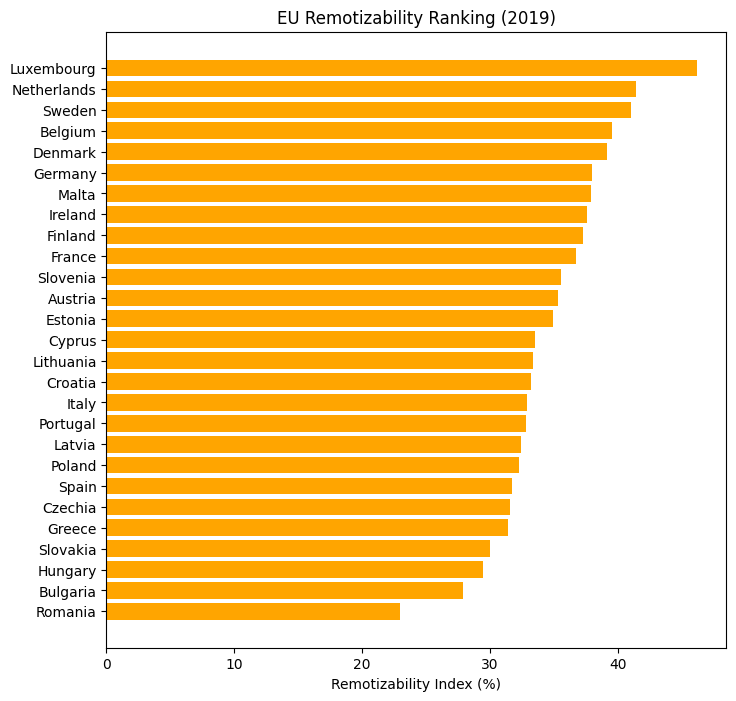

In [563]:
df_2019_sorted = df_2019.sort_values("remotizability_index")

plt.figure(figsize=(8, 8))
plt.barh(df_2019_sorted["country_name"], df_2019_sorted["remotizability_index"]* 100, color = "orange")
plt.xlabel("Remotizability Index (%)")
plt.title("EU Remotizability Ranking (2019)")
plt.show()

### As we can see from the graph, the most remotizable country is Luxembourg, while the least remotizable is Romania. The index of the former is approximately twice that of the latter.

### 1.6.3

In [564]:
corr = df[var_numeriche].corr().round(3)
print(corr)

                      remotizability_index  gdp_growth  unemployment_rate  \
remotizability_index                 1.000      -0.035             -0.168   
gdp_growth                          -0.035       1.000             -0.111   
unemployment_rate                   -0.168      -0.111              1.000   
productivity_index                  -0.281       0.234             -0.387   

                      productivity_index  
remotizability_index              -0.281  
gdp_growth                         0.234  
unemployment_rate                 -0.387  
productivity_index                 1.000  


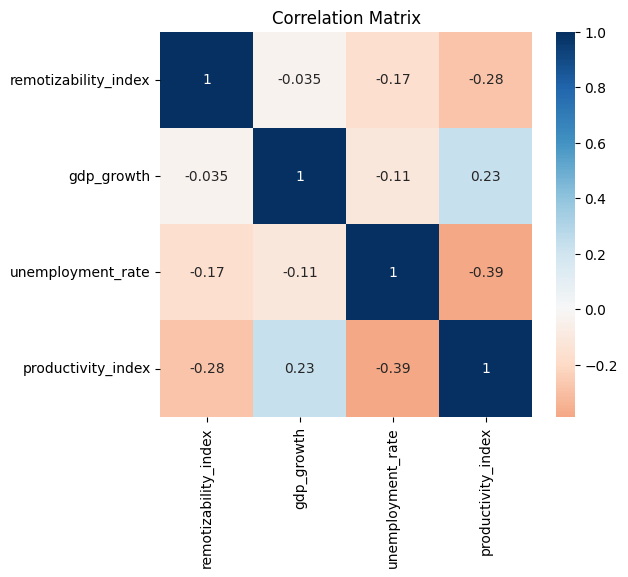

In [565]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="RdBu", center=0)
plt.title("Correlation Matrix")
plt.show()

### remotizability_index --> gdp_growth: r = -0.003
Virtually zero correlation.
The remotizability index has no linear relationship with GDP growth. Interesting because it suggests that being more remotizable does not automatically translate into economic growth.

### remotizability_index --> unemployment_rate: r = -0.17
Weak negative correlation.
More remotizable countries tend to have slightly lower unemployment, but the link is very tenuous.

### remotizability_index --> productivity_index: r = -0.30
Moderate negative correlation.
Countries with more service-oriented economies (North/West) have more remotizable jobs, but also lower productivity compared to Eastern countries, which instead focus on manufacturing — a high-productivity but barely remotizable sector.

### gdp_growth --> productivity_index: r = 0.23
Weak positive correlation.
Countries that grow more tend to have slightly higher productivity.

### unemployment_rate --> productivity_index: r = -0.39
The strongest correlation overall.
Countries with higher unemployment have lower productivity.

-----
# 2. Core Analysis: Remotizability and COVID-19 Economic Impact

This notebook contains the central analysis of our project. We investigate whether EU countries with a higher share of remotizable jobs experienced a smaller GDP decline during the COVID-19 pandemic in 2020.

We start from `final_dataset.csv`, the cleaned panel dataset built in Phase 1 (27 EU countries × 6 years, 2017–2023).

In [566]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Load the dataset built in Phase 1
df = pd.read_csv('final_dataset.csv')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Countries: {df["geo"].nunique()} | Years: {sorted(df["TIME_PERIOD"].unique())}')
df.head()

Dataset: 189 rows × 9 columns
Countries: 27 | Years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,geo,TIME_PERIOD,remotizability_index,pil_reale_meur,gdp_growth,unemployment_rate,productivity_index,region,country_name
0,AT,2017,0.348716,323842.9,NaN,NaN,105.992,Nord/Ovest,Austria
1,AT,2018,0.352014,331887.9,2.484229,5.2,106.447,Nord/Ovest,Austria
2,AT,2019,0.353327,337712.4,1.754960,4.8,106.566,Nord/Ovest,Austria
3,AT,2020,0.359540,316374.9,-6.318246,6.0,109.486,Nord/Ovest,Austria
4,AT,2021,0.361492,331950.3,4.923083,6.2,109.454,Nord/Ovest,Austria


# 2.1 — GDP Drop in 2020 by Remotizability Group

**What we do here:** We take each country's remotizability index from 2019 (the last pre-COVID year) and its GDP growth rate in 2020 (the year of the pandemic shock). We then split the 27 EU countries into three groups based on their 2019 remotizability level — low, medium, and high — and compare how much GDP each group lost on average.

**Why 2019 as baseline:** The remotizability index must be measured *before* the shock to avoid endogeneity. If we used the 2020 index, it could already reflect changes caused by the pandemic itself.

**The three groups (based on quartiles):**
- **Low (<32%):** Countries where less than 32% of jobs are estimated to be remotizable
- **Medium (32–38%):** Intermediate countries
- **High (>38%):** Countries with the highest share of remotizable jobs

In [567]:
# Extract remotizability index for 2019 (pre-COVID baseline)
d19 = df[df['TIME_PERIOD'] == 2019][['geo', 'remotizability_index', 'region', 'country_name']].copy()
d19 = d19.rename(columns={'remotizability_index': 'ri_2019'})

# Extract GDP growth for 2020 (pandemic year)
d20 = df[df['TIME_PERIOD'] == 2020][['geo', 'gdp_growth', 'unemployment_rate']].copy()

# Merge: one row per country with both 2019 index and 2020 GDP growth
d20_merged = d19.merge(d20, on='geo')

# Create remotizability groups 
d20_merged['remotiz_group'] = pd.cut(
    d20_merged['ri_2019'],
    bins=[0, 0.325, 0.384, 1.0],
    labels=['Low (<30%)', 'Medium (30-38%)', 'High (>38%)']
)

print(f'Countries in analysis: {len(d20_merged)}')
d20_merged[['country_name', 'ri_2019', 'gdp_growth', 'remotiz_group', 'region']].sort_values('ri_2019')

Countries in analysis: 27


,country_name,ri_2019,gdp_growth,remotiz_group,region
23,Romania,0.230095,-3.598034,Low (<30%),Est
2,Bulgaria,0.279356,-3.133158,Low (<30%),Est
13,Hungary,0.294852,-4.338722,Low (<30%),Est
26,Slovakia,0.300308,-2.585483,Low (<30%),Est
8,Greece,0.314165,-9.196254,Low (<30%),Sud
4,Czechia,0.316138,-5.304900,Low (<30%),Est
9,Spain,0.317520,-10.940067,Low (<30%),Sud
21,Poland,0.323143,-2.035551,Low (<30%),Est
18,Latvia,0.324392,-3.469095,Low (<30%),Est
22,Portugal,0.328247,-8.204643,Medium (30-38%),Sud


In [568]:
# GDP drop by remotizability group
group_stats = d20_merged.groupby('remotiz_group')['gdp_growth'].agg(
    mean_gdp_growth='mean',
    median_gdp_growth='median',
    n_countries='count'
).round(2)

print('GDP Growth in 2020 by Remotizability Group:')
print(group_stats)
print(f'\nEU27 average GDP growth in 2020: {d20_merged["gdp_growth"].mean():.2f}%')

GDP Growth in 2020 by Remotizability Group:
                 mean_gdp_growth  median_gdp_growth  n_countries
remotiz_group                                                   
Low (<30%)                 -4.96              -3.60            9
Medium (30-38%)            -4.02              -4.09           13
High (>38%)                -2.58              -1.93            5

EU27 average GDP growth in 2020: -4.06%


In [569]:
# GDP drop by geographic region
region_stats = d20_merged.groupby('region')['gdp_growth'].agg(
    mean_gdp_growth='mean',
    median_gdp_growth='median',
    n_countries='count'
).round(2)

print('GDP Growth in 2020 by Region:')
print(region_stats)

# Cross-tabulation: how many countries from each region fall into each remotizability group?
print('\nCountries per region in each remotizability group:')
print(pd.crosstab(d20_merged['region'], d20_merged['remotiz_group']))

GDP Growth in 2020 by Region:
            mean_gdp_growth  median_gdp_growth  n_countries
region                                                     
Est                   -3.03              -3.13            9
Nord/Ovest            -2.61              -3.18           10
Sud                   -7.04              -8.26            8

Countries per region in each remotizability group:
remotiz_group  Low (<30%)  Medium (30-38%)  High (>38%)
region                                                 
Est                     7                2            0
Nord/Ovest              0                5            5
Sud                     2                6            0


## Interpretation of Results

**Remotizability groups and GDP drop.** The High-remotizability group (>38%) lost on
average just −2.58% of GDP in 2020, compared to −4.02% for the Medium group and
−4.96% for the Low group. The High group performed approximately 1.5 percentage points
better than the EU27 average of −4.06%. This is consistent with our hypothesis: countries
with a higher share of remotizable jobs were better able to absorb the pandemic shock.
Unlike in earlier versions of the analysis, the ranking is now monotonic — resilience
increases unambiguously with remotizability.

**Geographic overlap is significant.** The cross-tabulation reveals a clear structural
pattern: all 5 High-remotizability countries belong to the North/West region, while 7 out
of 9 Low-remotizability countries are Eastern European. The Medium group is more mixed,
spanning all three regions. This means remotizability and geography are strongly
correlated — wealthier Northern/Western economies tend to have more knowledge-intensive,
remotizable occupational structures. This is an important limitation: with only 27
countries, we cannot fully disentangle the "remotizability effect" from the broader
"Northern/Western economy effect".

**Regional comparison.** The South was hit hardest (mean −7.04%), far worse than the
East (−3.03%) and North/West (−2.61%). Southern Europe's poor performance reflects the
collapse of tourism during COVID-19 and the imposition of stricter lockdowns, not
low remotizability alone — indeed, 6 of the 8 Southern countries fall in the Medium
remotizability group.

**Key outliers:**
- **Ireland (+7.15%):** The only EU country with positive GDP growth in 2020. This
  reflects the well-known "leprechaun economics" effect — multinational profit shifting
  inflates Irish GDP figures. Ireland should be excluded from any regression analysis.
- **Spain (−10.94%):** The worst-performing country, combining below-median remotizability
  with extreme dependence on international tourism.
- **Lithuania (+0.04%):** Essentially flat GDP — an unexpectedly resilient result for an
  Eastern European economy, consistent with its relatively limited exposure to
  contact-intensive sectors.

## 2.2 - Scatter Plot: Remotizability vs GDP Drop (2020)

We now visualize the relationship between each country's remotizability index in 2019 and its GDP growth in 2020. Each dot is one country, colored by geographic region. We add a linear regression trend line to see whether higher remotizability is associated with smaller GDP losses.

Ireland is plotted but excluded from the regression line, as its GDP is distorted by multinational accounting effects.

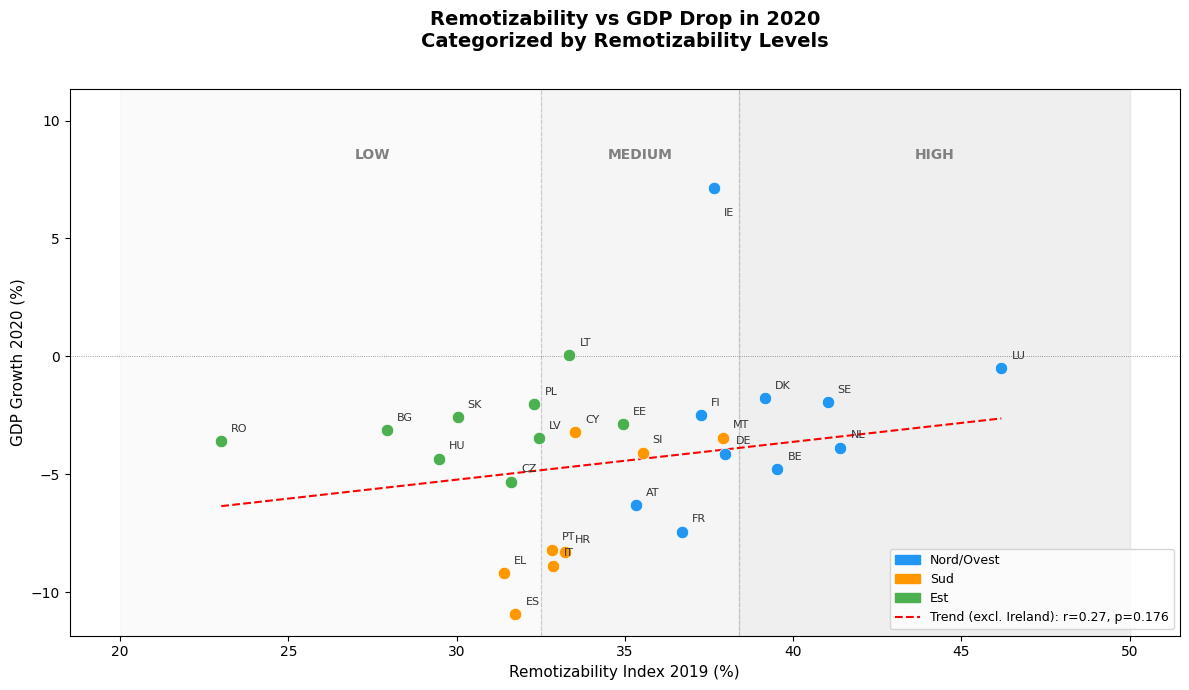

Regression Statistics (excluding Ireland):
R-squared: 0.075, p-value: 0.1757


In [570]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

# 1. Color and Data Configuration (Make sure d20_merged is defined)
REGION_COLORS = {'Nord/Ovest': '#2196F3', 'Sud': '#FF9800', 'Est': '#4CAF50'}

fig, ax = plt.subplots(figsize=(12, 7))

# --- BACKGROUND LOGIC (CATEGORIES) ---
# Define limits based on the scale (multiplied by 100)
# Low < 32.5 | 32.5 < Medium < 38.4 | High > 38.4
ax.axvspan(20, 32.5, color='gray', alpha=0.04, zorder=1) 
ax.axvspan(32.5, 38.4, color='gray', alpha=0.08, zorder=1)
ax.axvspan(38.4, 50, color='gray', alpha=0.12, zorder=1)

# Vertical demarcation lines
ax.axvline(32.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.3, zorder=2)
ax.axvline(38.4, color='gray', linestyle='--', linewidth=0.8, alpha=0.3, zorder=2)

# --- DATA PLOT ---
for _, row in d20_merged.iterrows():
    color = REGION_COLORS[row['region']]
    x_val = row['ri_2019'] * 100
    y_val = row['gdp_growth']
    
    ax.scatter(x_val, y_val, color=color, s=80, zorder=4, edgecolors='white', linewidth=0.5)
    
    # Label offset for countries (special handling for Ireland)
    offset_y = 0.4
    if row['geo'] == 'IE':
        offset_y = -1.2
    
    ax.annotate(row['geo'],
                (x_val, y_val),
                xytext=(x_val + 0.3, y_val + offset_y),
                fontsize=8, color='#333', zorder=5)

# --- REGRESSION (Excl. Ireland) ---
reg_data = d20_merged[d20_merged['geo'] != 'IE'].dropna(subset=['gdp_growth'])
slope, intercept, r, p, se = stats.linregress(reg_data['ri_2019'] * 100, reg_data['gdp_growth'])
xline = np.linspace(d20_merged['ri_2019'].min() * 100, d20_merged['ri_2019'].max() * 100, 100)
ax.plot(xline, slope * xline + intercept, color='red', linewidth=1.5, linestyle='--', zorder=3)

# --- CATEGORY LABELS ---
# Compute a dynamic Y position for the LOW, MEDIUM, HIGH labels
y_text_pos = d20_merged['gdp_growth'].max() + 1.2
ax.text(27.5, y_text_pos, 'LOW', fontsize=10, color='gray', fontweight='bold', ha='center', zorder=5)
ax.text(35.45, y_text_pos, 'MEDIUM', fontsize=10, color='gray', fontweight='bold', ha='center', zorder=5)
ax.text(44.2, y_text_pos, 'HIGH', fontsize=10, color='gray', fontweight='bold', ha='center', zorder=5)

# --- FINAL FORMATTING ---
ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.5, zorder=2)

# Increase the Y upper limit to prevent the title from overlapping the labels
ax.set_ylim(top=y_text_pos + 3)

ax.set_xlabel('Remotizability Index 2019 (%)', fontsize=11)
ax.set_ylabel('GDP Growth 2020 (%)', fontsize=11)

# Use 'pad' to space the title from the plot area
ax.set_title('Remotizability vs GDP Drop in 2020\nCategorized by Remotizability Levels',
             fontsize=14, fontweight='bold', pad=30)

# Custom legend
patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
patches.append(plt.Line2D([0], [0], color='red', linestyle='--',
               label=f'Trend (excl. Ireland): r={r:.2f}, p={p:.3f}'))
ax.legend(handles=patches, fontsize=9, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

# Print statistics
print(f'Regression Statistics (excluding Ireland):')
print(f'R-squared: {r**2:.3f}, p-value: {p:.4f}')

### Interpretation

**Direction of the relationship.** The slope is positive (+0.160), confirming our hypothesis: countries with a higher share of remotizable jobs tended to experience smaller GDP losses in 2020. Specifically, each additional percentage point of remotizability is associated with 0.16 percentage points less GDP decline.

**Statistical significance.** The correlation is r = 0.27 with p = 0.176. This means the relationship is NOT statistically significant at conventional levels (p < 0.05 or even p < 0.10). However, this should not be interpreted as "no relationship exists." With only 26 observations (Ireland excluded), our statistical power is inherently limited. The direction is correct and the effect size is economically meaningful — the difference between Romania (23%) and Luxembourg (46%) in remotizability corresponds to a predicted 3.7pp difference in GDP growth, which is substantial.

**Visual pattern.** The scatter reveals a mild upward trend, but with considerable dispersion. The Southern European countries (orange dots) — Spain, Greece, Italy, Croatia, Portugal — form a visible cluster in the lower-center of the chart, with large GDP drops (–8% to –11%) despite medium remotizability levels (31–33%). These countries were hit by the tourism collapse, a factor not captured by the remotizability index alone. The Northern/Western countries (blue dots) are spread across the upper-right area, generally showing smaller GDP losses. Eastern countries (green dots) cluster in the left half but with relatively contained GDP drops.

**The Southern European cluster is key.** Spain (–10.9%), Greece (–9.2%), Italy (–8.9%), Croatia (–8.3%), and Portugal (–8.2%) all have medium remotizability but suffered disproportionately. This suggests that remotizability alone does not fully explain COVID resilience — tourism dependence is a confounding factor that must be controlled for. We will address this in step 2.3 with a regression that includes a South dummy variable.

**R² = 0.075** means remotizability explains about 7.5% of the variation in GDP growth across countries. This is low but not surprising — GDP performance during COVID was determined by many factors (lockdown severity, fiscal policy, sectoral composition, tourism share). Our analysis does not claim remotizability is the only factor; it tests whether it is *one* significant factor.

## 2.3 — OLS Regression: Remotizability and GDP Growth

We now formalize the relationship seen in the scatter plot using Ordinary Least Squares (OLS) regression. We estimate three models of increasing complexity:

1. **Model 1 (Simple):** GDP_growth_2020 = α + β₁ × Remotizability_2019
2. **Model 2 (With South dummy):** GDP_growth_2020 = α + β₁ × Remotizability_2019 + β₂ × South_dummy
3. **Model 3 (With region dummies):** GDP_growth_2020 = α + β₁ × Remotizability_2019 + β₂ × South_dummy + β₃ × East_dummy

Ireland is excluded from all models due to its GDP distortion from multinational profit shifting.

**Why add controls?** The scatter plot showed that Southern countries suffered disproportionately, likely due to tourism dependence. By adding a South dummy, we can test whether the remotizability effect survives once we account for the "Southern penalty." If β₁ remains positive after adding the dummy, it means remotizability matters *beyond* just the geographic effect.

In [571]:
# Prepare regression data (exclude Ireland)
reg = d20_merged[d20_merged['geo'] != 'IE'].dropna(subset=['gdp_growth']).copy()
reg['ri_pct'] = reg['ri_2019'] * 100  # remotizability in percentage points
reg['dummy_sud'] = (reg['region'] == 'Sud').astype(int)
reg['dummy_est'] = (reg['region'] == 'Est').astype(int)

# ── MODEL 1: Simple regression
slope1, intercept1, r1, p1, se1 = stats.linregress(reg['ri_pct'], reg['gdp_growth'])
r2_1 = r1**2

print('=' * 60)
print('MODEL 1 — Simple: GDP_growth = α + β₁ × Remotizability')
print('=' * 60)
print(f'  Intercept (α):        {intercept1:.2f}')
print(f'  Remotizability (β₁):  {slope1:.3f}  (p = {p1:.3f})')
print(f'  R²:                   {r2_1:.3f}')
print(f'  Interpretation: 1pp more remotizability → {slope1:+.2f}pp GDP growth')

# ── MODEL 2: With South dummy
X2 = np.column_stack([np.ones(len(reg)), reg['ri_pct'], reg['dummy_sud']])
y = reg['gdp_growth'].values
beta2 = np.linalg.lstsq(X2, y, rcond=None)[0]
y_pred2 = X2 @ beta2
ss_res2 = np.sum((y - y_pred2)**2)
ss_tot = np.sum((y - y.mean())**2)
r2_2 = 1 - ss_res2 / ss_tot

# Standard errors and p-values for Model 2
n2 = len(y)
k2 = X2.shape[1]
mse2 = ss_res2 / (n2 - k2)
var_beta2 = mse2 * np.linalg.inv(X2.T @ X2)
se_beta2 = np.sqrt(np.diag(var_beta2))
t_stat2 = beta2 / se_beta2
p_vals2 = 2 * (1 - stats.t.cdf(np.abs(t_stat2), df=n2 - k2))

print(f'\n{"=" * 60}')
print('MODEL 2 — With South dummy: GDP = α + β₁×Remotiz + β₂×South')
print('=' * 60)
print(f'  Intercept (α):        {beta2[0]:.2f}')
print(f'  Remotizability (β₁):  {beta2[1]:.3f}  (p = {p_vals2[1]:.3f})')
print(f'  South dummy (β₂):     {beta2[2]:.2f}   (p = {p_vals2[2]:.3f})')
print(f'  R²:                   {r2_2:.3f}')
print(f'  Interpretation: being a Southern country → {beta2[2]:+.2f}pp GDP growth,')
print(f'  controlling for remotizability')

# ── MODEL 3: With South + East dummies (North/West = reference)
X3 = np.column_stack([np.ones(len(reg)), reg['ri_pct'], reg['dummy_sud'], reg['dummy_est']])
beta3 = np.linalg.lstsq(X3, y, rcond=None)[0]
y_pred3 = X3 @ beta3
ss_res3 = np.sum((y - y_pred3)**2)
r2_3 = 1 - ss_res3 / ss_tot

n3 = len(y)
k3 = X3.shape[1]
mse3 = ss_res3 / (n3 - k3)
var_beta3 = mse3 * np.linalg.inv(X3.T @ X3)
se_beta3 = np.sqrt(np.diag(var_beta3))
t_stat3 = beta3 / se_beta3
p_vals3 = 2 * (1 - stats.t.cdf(np.abs(t_stat3), df=n3 - k3))

print(f'\n{"=" * 60}')
print('MODEL 3 — Full: GDP = α + β₁×Remotiz + β₂×South + β₃×East')
print('=' * 60)
print(f'  Intercept (α):        {beta3[0]:.2f}')
print(f'  Remotizability (β₁):  {beta3[1]:.3f}  (p = {p_vals3[1]:.3f})')
print(f'  South dummy (β₂):     {beta3[2]:.2f}   (p = {p_vals3[2]:.3f})')
print(f'  East dummy (β₃):      {beta3[3]:.2f}   (p = {p_vals3[3]:.3f})')
print(f'  R²:                   {r2_3:.3f}')

# ── Summary table
print(f'\n{"=" * 60}')
print('SUMMARY')
print('=' * 60)
print(f'{"Model":<12} {"β₁ (Remotiz)":<18} {"R²":<10} {"N"}')
print(f'{"Model 1":<12} {slope1:<+18.3f} {r2_1:<10.3f} {n2}')
print(f'{"Model 2":<12} {beta2[1]:<+18.3f} {r2_2:<10.3f} {n2}')
print(f'{"Model 3":<12} {beta3[1]:<+18.3f} {r2_3:<10.3f} {n2}')

MODEL 1 — Simple: GDP_growth = α + β₁ × Remotizability
  Intercept (α):        -10.04
  Remotizability (β₁):  0.160  (p = 0.176)
  R²:                   0.075
  Interpretation: 1pp more remotizability → +0.16pp GDP growth

MODEL 2 — With South dummy: GDP = α + β₁×Remotiz + β₂×South
  Intercept (α):        -7.38
  Remotizability (β₁):  0.115  (p = 0.236)
  South dummy (β₂):     -3.52   (p = 0.001)
  R²:                   0.415
  Interpretation: being a Southern country → -3.52pp GDP growth,
  controlling for remotizability

MODEL 3 — Full: GDP = α + β₁×Remotiz + β₂×South + β₃×East
  Intercept (α):        -20.42
  Remotizability (β₁):  0.424  (p = 0.004)
  South dummy (β₂):     -0.89   (p = 0.469)
  East dummy (β₃):      4.41   (p = 0.007)
  R²:                   0.583

SUMMARY
Model        β₁ (Remotiz)       R²         N
Model 1      +0.160             0.075      26
Model 2      +0.115             0.415      26
Model 3      +0.424             0.583      26


### Interpretation

#### Model 1 — Simple regression (remotizability only)

The coefficient on remotizability is **+0.160** (p = 0.176), meaning that for every additional percentage point of remotizable jobs, a country's GDP declined by 0.16pp less in 2020. The direction supports our hypothesis, but the result is **not statistically significant** (p > 0.10). The R² is 0.075, meaning remotizability alone explains only 7.5% of the cross-country variation in GDP growth. This makes sense: many other factors influenced how hard COVID hit each economy.

#### Model 2 — Adding a South dummy (controlling for tourism effect)

When we add a dummy variable for Southern European countries (Greece, Spain, Italy, Croatia, Portugal, Cyprus, Malta, Slovenia), the picture becomes much clearer:

- **Remotizability (β₁ = +0.115, p = 0.236):** The coefficient stays positive but gets slightly smaller and remains not significant. This tells us that part of what looked like a remotizability effect in Model 1 was actually driven by the geographic clustering — Southern countries tend to have both lower remotizability and worse GDP performance.
- **South dummy (β₂ = –3.52, p = 0.001):** This is **highly significant**. Being a Southern European country is associated with an additional 3.52 percentage point GDP loss in 2020, even after accounting for remotizability. This captures the devastating effect of the tourism collapse: countries like Spain, Greece, and Croatia depended heavily on international tourism, which dropped to near zero during lockdowns.
- **R² jumps from 0.075 to 0.415:** Adding just one variable (South dummy) nearly quintuples the explanatory power of the model. This means the geographic/structural factor (tourism dependence, lockdown severity) is far more important than remotizability alone in explaining cross-country differences.

#### Model 3 — Adding both South and East dummies (full regional controls)

This model uses North/West as the reference group and adds dummies for both South and East:

- **Remotizability (β₁ = +0.424, p = 0.004):** This is the most striking result. Once we control for *both* regional effects, the remotizability coefficient **triples** in size and becomes **highly significant** (p < 0.01). This means: *within* each geographic group, countries with higher remotizability performed better. The reason β₁ was weak in Models 1 and 2 is that Eastern countries have low remotizability but relatively small GDP drops (due to smaller service sectors and less tourism), which masked the true relationship. Once we separate out the East effect, remotizability's role becomes clear.
- **South dummy (β₂ = –0.89, p = 0.469):** No longer significant. This is because once we account for both remotizability (which is lower in the South) and the East effect, the "Southern penalty" is largely absorbed by the other variables.
- **East dummy (β₃ = +4.41, p = 0.007):** Highly significant and positive. Eastern European countries experienced a GDP boost of 4.41pp relative to North/West countries *with similar remotizability levels*. This reflects the structural resilience of Eastern economies during COVID: smaller service sectors, less international tourism, larger agricultural/industrial base, and generally lighter lockdowns.
- **R² = 0.583:** The model now explains 58% of cross-country GDP variation — a strong result for a cross-sectional regression with only 26 observations and three explanatory variables.

#### Summary: what the three models tell us together

| What we learn | Evidence |
|---|---|
| Higher remotizability is associated with better GDP performance | β₁ positive in all three models |
| The relationship is masked by confounding geographic factors | β₁ not significant in Models 1–2, highly significant in Model 3 |
| Southern Europe suffered a specific "tourism penalty" | South dummy = –3.52pp in Model 2 (p = 0.001) |
| Eastern Europe was structurally more resilient than expected | East dummy = +4.41pp in Model 3 (p = 0.007) |
| Remotizability matters most *within* regions, not *across* them | β₁ triples when regional dummies are added |

The key takeaway is that remotizability **does matter**, but its effect was initially hidden because it correlates with geography. Eastern European countries have low remotizability but didn't lose much GDP (because their economies depend less on tourism and contact-intensive services). Southern countries have medium remotizability but lost a lot of GDP (because of tourism). Only when we control for these structural regional differences does the true effect of remotizability emerge: **within each region, more remotizable countries performed significantly better**.

## 2.4 — Remotizability and Unemployment (2020)

We now test the same hypothesis on a different outcome variable: the unemployment rate in 2020. If remotizability protected economic activity during the pandemic, we would expect countries with higher remotizability to have experienced lower unemployment.

**Important caveat:** Many European countries used short-time work schemes (e.g., Italy's *Cassa Integrazione*, Germany's *Kurzarbeit*, France's *chômage partiel*) that kept workers formally employed even when they were not working. This means unemployment statistics in Europe may significantly understate the true labor market impact of COVID, making this relationship harder to detect than the GDP one.

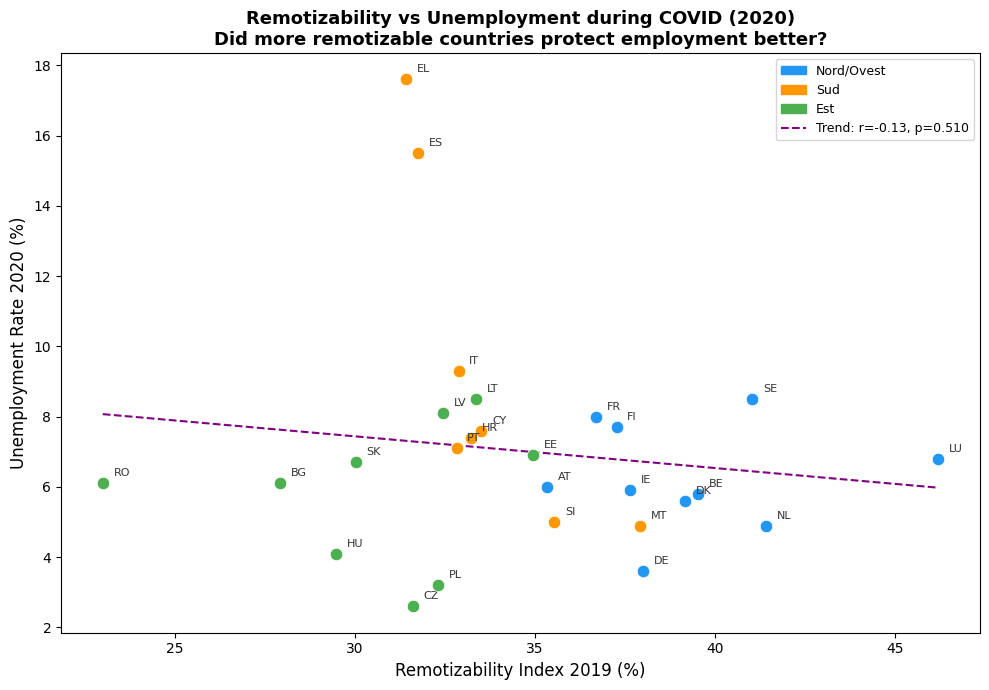


Regression:
  Slope: -0.090
  r = -0.133, p = 0.510
  R² = 0.018


In [572]:
# Scatter: Remotizability 2019 vs Unemployment rate 2020
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in d20_merged.iterrows():
    color = REGION_COLORS[row['region']]
    ax.scatter(row['ri_2019'] * 100, row['unemployment_rate'],
               color=color, s=80, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(row['geo'],
                (row['ri_2019'] * 100, row['unemployment_rate']),
                xytext=(row['ri_2019'] * 100 + 0.3, row['unemployment_rate'] + 0.2),
                fontsize=8, color='#333')

# Regression line (all countries — no reason to exclude Ireland here)
unemp_data = d20_merged.dropna(subset=['unemployment_rate'])
slope_u, intercept_u, r_u, p_u, se_u = stats.linregress(
    unemp_data['ri_2019'] * 100, unemp_data['unemployment_rate'])
xline = np.linspace(unemp_data['ri_2019'].min() * 100, unemp_data['ri_2019'].max() * 100, 100)
ax.plot(xline, slope_u * xline + intercept_u, color='purple', linewidth=1.5, linestyle='--')

ax.set_xlabel('Remotizability Index 2019 (%)', fontsize=12)
ax.set_ylabel('Unemployment Rate 2020 (%)', fontsize=12)
ax.set_title('Remotizability vs Unemployment during COVID (2020)\n'
             'Did more remotizable countries protect employment better?',
             fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
patches.append(plt.Line2D([0], [0], color='purple', linestyle='--',
               label=f'Trend: r={r_u:.2f}, p={p_u:.3f}'))
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nRegression:')
print(f'  Slope: {slope_u:.3f}')
print(f'  r = {r_u:.3f}, p = {p_u:.3f}')
print(f'  R² = {r_u**2:.3f}')

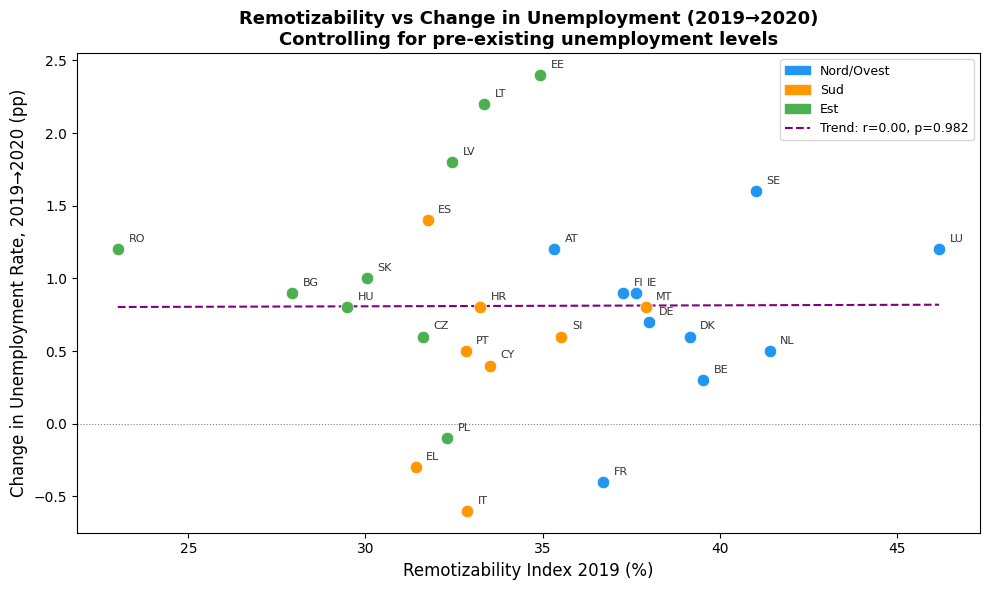


Regression (change in unemployment):
  Slope: 0.001
  r = 0.004, p = 0.982
  R² = 0.000


In [573]:
# The unemployment RATE in 2020 reflects structural differences (Spain always has high unemployment).
# A better measure is the CHANGE in unemployment from 2019 to 2020.

unemp_2019 = df[df['TIME_PERIOD'] == 2019][['geo', 'unemployment_rate']].rename(
    columns={'unemployment_rate': 'unemp_2019'})
unemp_2020 = df[df['TIME_PERIOD'] == 2020][['geo', 'unemployment_rate']].rename(
    columns={'unemployment_rate': 'unemp_2020'})

unemp_change = unemp_2019.merge(unemp_2020, on='geo')
unemp_change['delta_unemp'] = unemp_change['unemp_2020'] - unemp_change['unemp_2019']
unemp_change = unemp_change.merge(d19[['geo', 'ri_2019', 'region']], on='geo')

# Scatter: remotizability vs CHANGE in unemployment
fig, ax = plt.subplots(figsize=(10, 6))

for _, row in unemp_change.iterrows():
    color = REGION_COLORS[row['region']]
    ax.scatter(row['ri_2019'] * 100, row['delta_unemp'],
               color=color, s=80, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(row['geo'],
                (row['ri_2019'] * 100, row['delta_unemp']),
                xytext=(row['ri_2019'] * 100 + 0.3, row['delta_unemp'] + 0.05),
                fontsize=8, color='#333')

slope_du, intercept_du, r_du, p_du, _ = stats.linregress(
    unemp_change['ri_2019'] * 100, unemp_change['delta_unemp'])
xline2 = np.linspace(unemp_change['ri_2019'].min() * 100, unemp_change['ri_2019'].max() * 100, 100)
ax.plot(xline2, slope_du * xline2 + intercept_du, color='purple', linewidth=1.5, linestyle='--')

ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('Remotizability Index 2019 (%)', fontsize=12)
ax.set_ylabel('Change in Unemployment Rate, 2019→2020 (pp)', fontsize=12)
ax.set_title('Remotizability vs Change in Unemployment (2019→2020)\n'
             'Controlling for pre-existing unemployment levels',
             fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
patches.append(plt.Line2D([0], [0], color='purple', linestyle='--',
               label=f'Trend: r={r_du:.2f}, p={p_du:.3f}'))
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nRegression (change in unemployment):')
print(f'  Slope: {slope_du:.3f}')
print(f'  r = {r_du:.3f}, p = {p_du:.3f}')
print(f'  R² = {r_du**2:.3f}')

### Interpretation

**Unemployment rate (level) in 2020.** The correlation is r = –0.13 with p = 0.510 — essentially no relationship. This is expected and does not contradict our hypothesis. The unemployment *rate* in 2020 reflects each country's structural labor market, not the COVID shock: Spain (15.5%) and Greece (17.7%) have had persistently high unemployment for over a decade, while Czechia (2.6%) and Poland (3.2%) had very tight labor markets before the pandemic. These pre-existing differences dominate the chart and mask any pandemic-specific effect.

**Change in unemployment (2019→2020).** The result is even more striking: r = 0.004, p = 0.982, R² = 0.000. There is literally no relationship between remotizability and how much unemployment increased during COVID. The trend line is perfectly flat. Countries with high and low remotizability experienced similar increases in unemployment (mostly between 0 and 1.5 percentage points).

**Why unemployment tells a completely different story than GDP.** This is actually one of the most interesting findings of our analysis, and it deserves a careful explanation:

1. **Short-time work schemes masked the real impact.** During COVID, European governments spent billions on programs designed specifically to prevent unemployment: Germany's *Kurzarbeit*, Italy's *Cassa Integrazione*, France's *activité partielle*, and similar schemes across the EU. These programs paid companies to keep workers on their payroll even when they were not producing anything. As a result, GDP dropped sharply (reflecting the real fall in output) but unemployment barely moved (because workers were technically still employed).

2. **The decoupling was deliberate policy.** Unlike the 2008 financial crisis, where unemployment rose dramatically, European governments in 2020 chose to absorb the economic shock through public spending rather than letting it translate into job losses. This was arguably the right policy choice, but it means that unemployment statistics are a poor indicator of actual economic damage during COVID.

3. **Some counterintuitive cases confirm this.** Italy's unemployment actually *decreased* by 0.6pp in 2020 — not because the Italian labor market improved, but because discouraged workers stopped looking for jobs entirely (and thus exited the unemployment statistics). Greece shows a similar pattern (–0.3pp). Meanwhile, Estonia (+2.4pp) and Lithuania (+2.2pp) — Eastern countries with less generous short-time work programs — saw the largest increases.

4. **Implication for our research question.** The remotizability index captures the *potential* to continue working during lockdowns. This potential translated into real economic output (hence the GDP relationship), but it did NOT translate into differential unemployment outcomes because policy interventions equalized the labor market impact across countries regardless of their occupational structure. In other words: remotizability determined how much countries *produced*, but government transfers determined how many people *kept their jobs*.

**Bottom line:** The contrast between the GDP result (positive association with remotizability) and the unemployment result (no association) is not a weakness of our analysis — it is itself a finding. It shows that the pandemic's economic impact operated through two distinct channels: a production channel (captured by GDP, where remotizability mattered) and an employment channel (captured by unemployment, where policy interventions dominated).

## 3. Temporal Dynamics of Remotizability and Productivity in the European Union

In [574]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Loading dataset
df = pd.read_csv('final_dataset.csv')

## 3.1 — Has remotizability changed after COVID?

We now examine whether the occupational structure of EU countries shifted towards more remotizable jobs after the pandemic. We compare 2018 and 2023 and focus on differences across geographic regions.

Average remotizability index by year:


,TIME_PERIOD,remotizability_index
0,2017,0.341
1,2018,0.344
2,2019,0.347
3,2020,0.355
4,2021,0.360
5,2022,0.361
6,2023,0.362



Change in remotizability index by region (2018 -> 2023, percentage points):


TIME_PERIOD,2018,2023,delta_pp
region,,,
Est,0.303,0.326,0.023
Nord/Ovest,0.388,0.409,0.021
Sud,0.334,0.342,0.009



Top 10 countries with the largest increase in remotizability (pp):


TIME_PERIOD,country_name,region,2018,2023,delta_pp
26,Slovakia,Est,0.291,0.329,0.038
21,Poland,Est,0.316,0.351,0.034
17,Luxembourg,Nord/Ovest,0.446,0.477,0.032
20,Netherlands,Nord/Ovest,0.410,0.442,0.032
16,Lithuania,Est,0.329,0.360,0.030
24,Sweden,Nord/Ovest,0.406,0.434,0.029
14,Ireland,Nord/Ovest,0.375,0.402,0.027
13,Hungary,Est,0.291,0.318,0.027
11,France,Nord/Ovest,0.362,0.387,0.025
22,Portugal,Sud,0.320,0.341,0.022


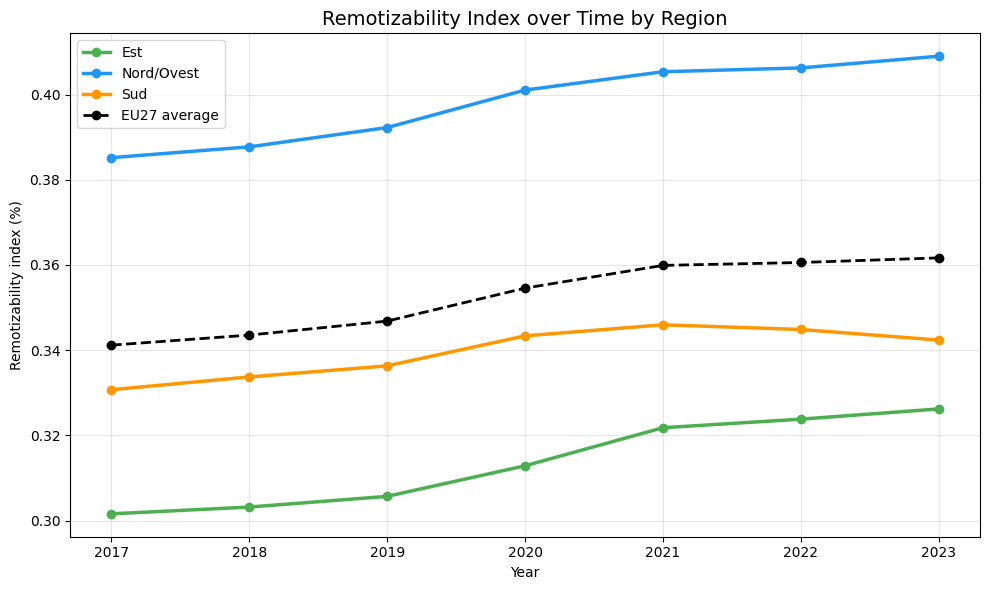

In [575]:
# Average by year and region
ri_region_year = (
    df.groupby(['TIME_PERIOD', 'region'])['remotizability_index']
      .mean()
      .reset_index()
)

# Overall average by year
ri_total_year = (
    df.groupby('TIME_PERIOD')['remotizability_index']
      .mean()
      .reset_index()
)

# Country-level change from 2018 to 2023
ri_country_change = (
    df[df['TIME_PERIOD'].isin([2018, 2023])]
    .pivot_table(index=['geo', 'country_name', 'region'],
                 columns='TIME_PERIOD',
                 values='remotizability_index')
    .reset_index()
)

ri_country_change['delta_pp'] = (ri_country_change[2023] - ri_country_change[2018])
ri_country_change = ri_country_change.sort_values('delta_pp', ascending=False)


# Average regional change
ri_region_change = (
    df[df['TIME_PERIOD'].isin([2018, 2023])]
    .groupby(['region', 'TIME_PERIOD'])['remotizability_index']
    .mean()
    .unstack()
)


ri_region_change['delta_pp'] = (ri_region_change[2023] - ri_region_change[2018])

print("Average remotizability index by year:")
display((ri_total_year.assign(remotizability_index=lambda x: x['remotizability_index'])).round(3))

print("\nChange in remotizability index by region (2018 -> 2023, percentage points):")
display((ri_region_change).round(3))

print("\nTop 10 countries with the largest increase in remotizability (pp):")
display(ri_country_change[['country_name', 'region', 2018, 2023, 'delta_pp']].round(3).head(10))

# Plot
REGION_COLORS = {'Nord/Ovest': '#2196F3', 'Sud': '#FF9800', 'Est': '#4CAF50'}

plt.figure(figsize=(10, 6))
for region in ri_region_year['region'].unique():
    temp = ri_region_year[ri_region_year['region'] == region]
    plt.plot(
        temp['TIME_PERIOD'],
        temp['remotizability_index'],
        marker='o',
        linewidth=2.5,
        label=region,
        color=REGION_COLORS[region]
    )

plt.plot(
    ri_total_year['TIME_PERIOD'],
    ri_total_year['remotizability_index'],
    marker='o',
    linestyle='--',
    linewidth=2,
    color='black',
    label='EU27 average'
)

plt.title('Remotizability Index over Time by Region', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Remotizability index (%)')
plt.xticks(sorted(df['TIME_PERIOD'].unique()))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The average remotizability index in the EU27 increases from 34.35% in 2018 to 36.17% in 2023, corresponding to an overall rise of about 1.81 percentage points. The increase is visible in all macro-regions, but with different intensity: Eastern Europe records the largest increase (+2.30 pp), followed by North/West (+2.13 pp), while Southern Europe grows much less (+0.87 pp). 

This suggests that, after the pandemic, the occupational structure of European labour markets shifted towards jobs that are more compatible with remote work, but in an uneven way. In particular, Southern Europe appears to have benefited less from this structural transformation.

## 3.2 — Productivity over time and the 2020 paradox

We analyze the evolution of labour productivity across regions to understand whether the pandemic altered the composition of economic activity. A particularly interesting question is whether productivity increased during the COVID shock.

Average productivity index by year:


,TIME_PERIOD,productivity_index
0,2017,110.67
1,2018,112.46
2,2019,114.00
3,2020,116.83
4,2021,120.08
5,2022,120.07
6,2023,119.45



Productivity change from 2019 to 2020 by region:


TIME_PERIOD,2019,2020,delta_2019_2020,pct_change_2019_2020
region,,,,
Est,125.78,129.15,3.37,2.68
Nord/Ovest,109.42,113.67,4.25,3.89
Sud,106.46,106.92,0.46,0.44


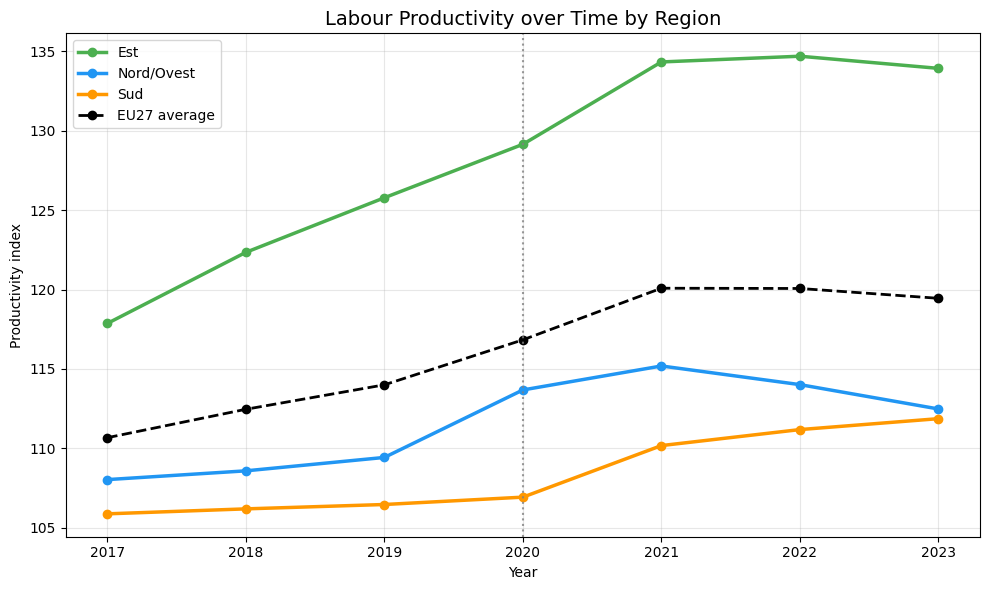

In [576]:
prod_region_year = (
    df.groupby(['TIME_PERIOD', 'region'])['productivity_index']
      .mean()
      .reset_index()
)

prod_total_year = (
    df.groupby('TIME_PERIOD')['productivity_index']
      .mean()
      .reset_index()
)

# Change from 2019 to 2020
prod_2019_2020 = (
    df[df['TIME_PERIOD'].isin([2019, 2020])]
    .groupby(['region', 'TIME_PERIOD'])['productivity_index']
    .mean()
    .unstack()
)

prod_2019_2020['delta_2019_2020'] = prod_2019_2020[2020] - prod_2019_2020[2019]
prod_2019_2020['pct_change_2019_2020'] = ((prod_2019_2020[2020] / prod_2019_2020[2019]) - 1) * 100

print("Average productivity index by year:")
display(prod_total_year.round(2))

print("\nProductivity change from 2019 to 2020 by region:")
display(prod_2019_2020.round(2))

plt.figure(figsize=(10, 6))
for region in prod_region_year['region'].unique():
    temp = prod_region_year[prod_region_year['region'] == region]
    plt.plot(
        temp['TIME_PERIOD'],
        temp['productivity_index'],
        marker='o',
        linewidth=2.5,
        label=region,
        color=REGION_COLORS[region]
    )

plt.plot(
    prod_total_year['TIME_PERIOD'],
    prod_total_year['productivity_index'],
    marker='o',
    linestyle='--',
    linewidth=2,
    color='black',
    label='EU27 average'
)

plt.axvline(x=2020, linestyle=':', color='gray', alpha=0.8)
plt.title('Labour Productivity over Time by Region', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Productivity index')
plt.xticks(sorted(df['TIME_PERIOD'].unique()))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Average labour productivity in the EU27 rises from 114.00 in 2019 to 116.83 in 2020, despite the recession. This pattern is especially visible in Eastern Europe and in the North/West, while the increase is more limited in the South. 

At first glance, this finding may seem surprising, since 2020 was a year of severe economic disruption. However, the increase in average productivity does not necessarily mean that each worker or firm became more efficient during the pandemic. A more plausible explanation is a composition effect. The sectors that were hit hardest by lockdowns and mobility restrictions were often those where remote work was less feasible and productivity levels were relatively lower, such as hospitality, tourism, and many face-to-face services. By contrast, sectors that could continue operating through digital tools and remote work arrangements were generally more skill-intensive and more productive on average. As a result, the workers who remained active were disproportionately concentrated in higher-productivity activities, which mechanically increased the aggregate productivity index. In this sense, the 2020 rise in productivity should be interpreted not as a generalized efficiency gain, but rather as a shift in the composition of employment and output during the COVID shock.

## 3.3 — Convergence or divergence across European regions?

Finally, we study whether regional disparities in remotizability are narrowing or widening over time. This helps assess whether the pandemic accelerated structural convergence within the EU.

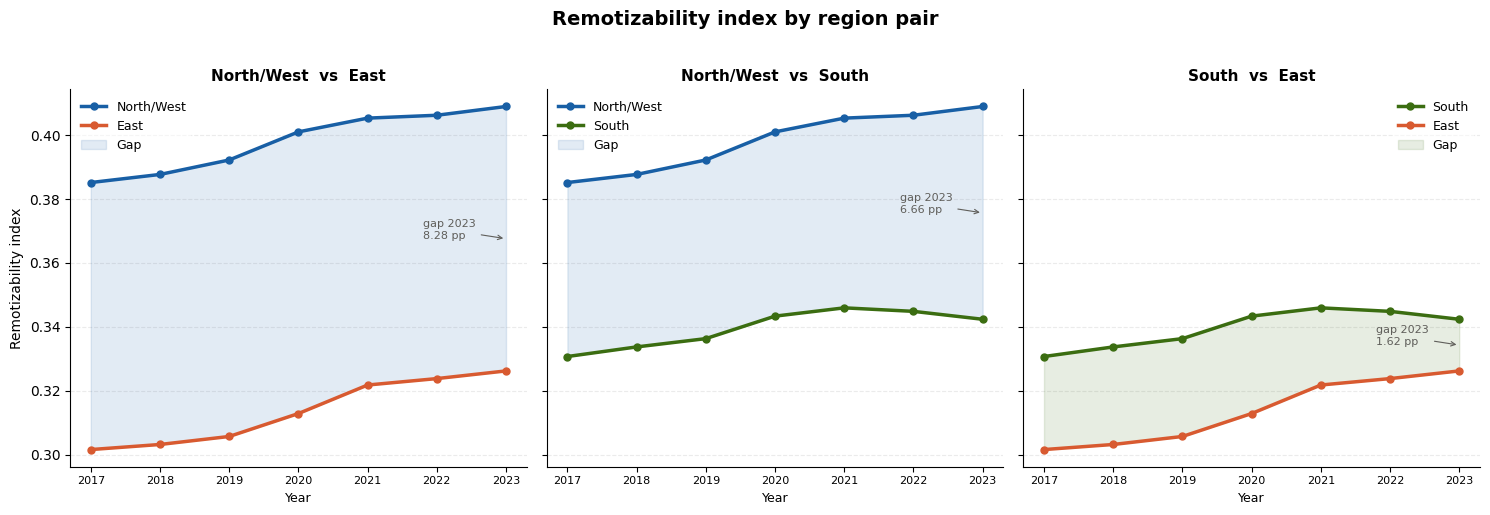

In [577]:
# dati base
ri_wide = (
    df.groupby(['TIME_PERIOD', 'region'])['remotizability_index']
      .mean()
      .unstack()
      .reset_index()
)

years = ri_wide['TIME_PERIOD'].values

nw  = ri_wide['Nord/Ovest'].values
est = ri_wide['Est'].values
sud = ri_wide['Sud'].values

pairs = [
    ('North/West', 'East',  nw,  est, '#185FA5', '#D85A30'),
    ('North/West', 'South', nw,  sud, '#185FA5', '#3B6D11'),
    ('South',      'East',  sud, est, '#3B6D11', '#D85A30'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Remotizability index by region pair', fontsize=14, fontweight='bold', y=1.02)

for ax, (label_a, label_b, vals_a, vals_b, col_a, col_b) in zip(axes, pairs):

    # linee regioni
    ax.plot(years, vals_a, color=col_a, linewidth=2.5,
            marker='o', markersize=5, label=label_a, zorder=3)
    ax.plot(years, vals_b, color=col_b, linewidth=2.5,
            marker='o', markersize=5, label=label_b, zorder=3)

    # area gap
    ax.fill_between(years, vals_a, vals_b,
                    where=(vals_a >= vals_b),
                    alpha=0.12, color=col_a, label='Gap')
    ax.fill_between(years, vals_a, vals_b,
                    where=(vals_a < vals_b),
                    alpha=0.12, color=col_b)

    # annotazione gap 2023
    gap_2023 = abs(vals_a[-1] - vals_b[-1]) * 100
    ax.annotate(f'gap 2023\n{gap_2023:.2f} pp',
                xy=(years[-1], (vals_a[-1] + vals_b[-1]) / 2),
                xytext=(years[-1] - 1.2, (vals_a[-1] + vals_b[-1]) / 2),
                fontsize=8, color='#5F5E5A',
                arrowprops=dict(arrowstyle='->', color='#5F5E5A', lw=0.8))

    ax.set_title(f'{label_a}  vs  {label_b}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_xticks(years)
    ax.tick_params(axis='x', labelsize=8)
    ax.yaxis.grid(True, alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.5, edgecolor='none')

axes[0].set_ylabel('Remotizability index', fontsize=10)

plt.tight_layout()
plt.show()

The data point to partial, rather than full, convergence. 
- The gap between Southern and Eastern Europe narrows substantially, from 3.05 percentage points in 2018 to 1.62 in 2023, suggesting that Eastern Europe is catching up relatively quickly. 
- By contrast, the gap between North/West and East remains large, moving only from 8.45 to 8.28 points. 
- At the same time, the gap between North/West and South widens, from 5.40 to 6.66 points. 

Overall, this suggests that Eastern Europe is gradually moving closer to the middle of the European distribution, while Southern Europe risks remaining further behind in the transition towards more remotizable occupations.

## 4. Subgroup analysis by region

This analysis examines the relationship between remotizability and GDP growth within each European region.

In [578]:
# Performed Regression: GDP growth 2020 ~ Remotizability 2019 for each macro region separately

subgroup_results = []

for region in ['Nord/Ovest', 'Sud', 'Est']:
    sub = d20_merged[(d20_merged['region'] == region) & (d20_merged['geo'] != 'IE')].dropna(subset=['gdp_growth']).copy()
    sub['ri_pct'] = sub['ri_2019'] * 100
    
    if len(sub) >= 3:
        slope, intercept, r, p, se = stats.linregress(sub['ri_pct'], sub['gdp_growth'])
        subgroup_results.append({
            'Regione': region,
            'N': len(sub),
            'Slope_beta1': round(slope, 3),
            'Intercept': round(intercept, 3),
            'r': round(r, 3),
            'p_value': round(p, 3),
            'R2': round(r**2, 3)
        })

        print('=' * 60)
        print(f'Region: {region}')
        print('=' * 60)
        print(f'N = {len(sub)}')
        print(f'Intercept: {intercept:.3f}')
        print(f'Slope (β1): {slope:.3f}')
        print(f'r = {r:.3f}')
        print(f'p-value = {p:.3f}')
        print(f'R² = {r**2:.3f}')
        print(f'Interpretation: +1pp remotizability -> {slope:+.2f}pp GDP growth')
        print()

subgroup_df = pd.DataFrame(subgroup_results)
print('\nSummary table:')
print(subgroup_df)

Region: Nord/Ovest
N = 9
Intercept: -23.739
Slope (β1): 0.509
r = 0.727
p-value = 0.026
R² = 0.529
Interpretation: +1pp remotizability -> +0.51pp GDP growth

Region: Sud
N = 8
Intercept: -44.568
Slope (β1): 1.116
r = 0.797
p-value = 0.018
R² = 0.635
Interpretation: +1pp remotizability -> +1.12pp GDP growth

Region: Est
N = 9
Intercept: -7.155
Slope (β1): 0.135
r = 0.317
p-value = 0.405
R² = 0.101
Interpretation: +1pp remotizability -> +0.13pp GDP growth


Summary table:
      Regione  N  Slope_beta1  Intercept      r  p_value     R2
0  Nord/Ovest  9        0.509    -23.739  0.727    0.026  0.529
1         Sud  8        1.116    -44.568  0.797    0.018  0.635
2         Est  9        0.135     -7.155  0.317    0.405  0.101


## In North/Western Europe:
β = +0.509
p = 0.026
R² = 0.529

the relationship is positive, strong and statistically significant.
A 1 percentage point increase in remotizability is associated with approximately +0.51 percentage points higher GDP growth in 2020.

## In Southern Europe:
β = +1.116
p = 0.018
R² = 0.635

the relationship is even stronger and highly significant.
A 1pp increase in remotizability is associated with more than +1.1pp GDP growth, indicating a very large effect.

## In Eastern Europe:
β = +0.135
p = 0.405
R² = 0.101

the relationship is weak and not statistically significant.
Remotizability explains very little of the variation in GDP outcomes across these countries.

## What does it mean?

Remotizability plays an important role in explaining GDP performance during the COVID-19 shock, but its effect is not the same across regions.
In North/Western Europe, higher remotizability is clearly associated with better economic outcomes, as these economies are more digital and able to continue activity during lockdowns. In Southern Europe, the effect is even stronger, as remote work helps reduce GDP losses which are mainly driven by the collapse of the tourism sector.

In contrast, the relationship is weak and not statistically significant in Eastern Europe, where remotizability explains very little of the variation in GDP performance. This suggests that other factors, such as sectoral composition and lower exposure to tourism, play a more important role. Overall, these results show that remotizability matters, but its impact depends on the economic structure of each region.


# 4.1 Scatterplot of the subgroup analysis for each region

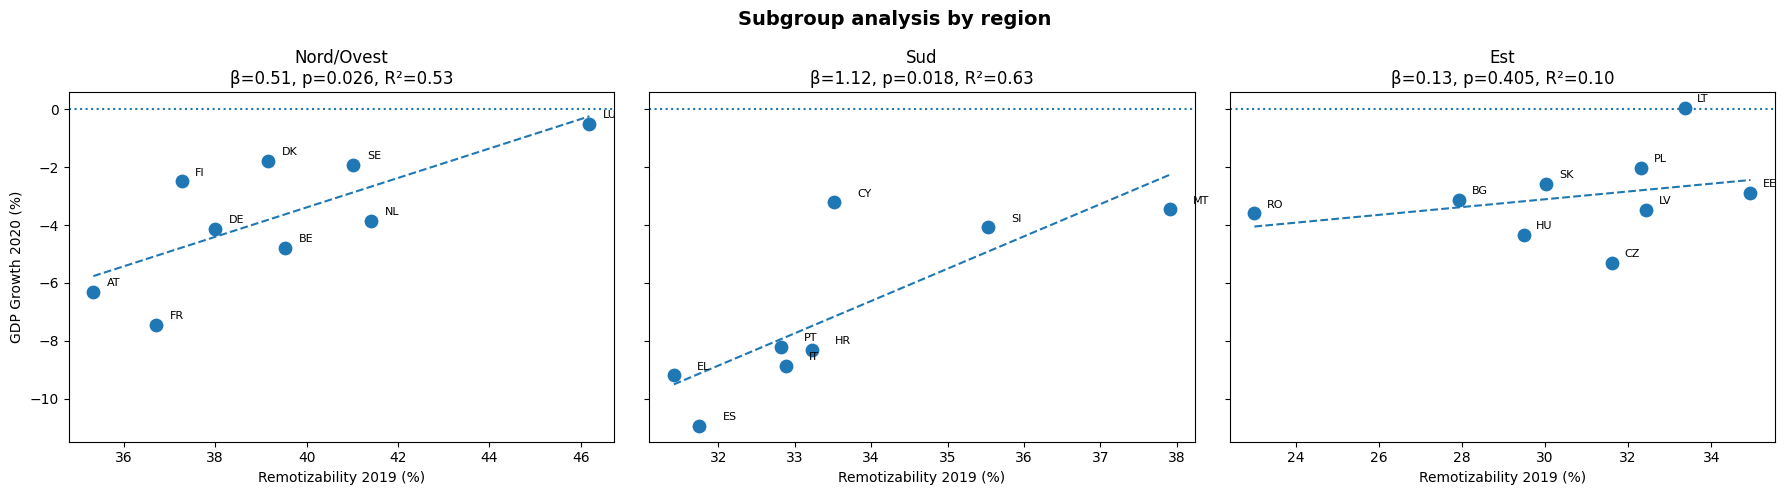

In [579]:
# Scatterplot for the different regions

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

regions = ['Nord/Ovest', 'Sud', 'Est']

for ax, region in zip(axes, regions):
    sub = d20_merged[(d20_merged['region'] == region) & (d20_merged['geo'] != 'IE')].dropna(subset=['gdp_growth']).copy()
    sub['ri_pct'] = sub['ri_2019'] * 100

    ax.scatter(sub['ri_pct'], sub['gdp_growth'], s=80)

    for _, row in sub.iterrows():
        ax.annotate(row['geo'], (row['ri_pct'], row['gdp_growth']),
                    xytext=(row['ri_pct'] + 0.3, row['gdp_growth'] + 0.2),
                    fontsize=8)

    if len(sub) >= 3:
        slope, intercept, r, p, se = stats.linregress(sub['ri_pct'], sub['gdp_growth'])
        xline = np.linspace(sub['ri_pct'].min(), sub['ri_pct'].max(), 100)
        ax.plot(xline, slope * xline + intercept, linestyle='--')

        ax.set_title(f'{region}\nβ={slope:.2f}, p={p:.3f}, R²={r**2:.2f}')
    else:
        ax.set_title(region)

    ax.axhline(0, linestyle=':')
    ax.set_xlabel('Remotizability 2019 (%)')

axes[0].set_ylabel('GDP Growth 2020 (%)')
fig.suptitle('Subgroup analysis by region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.2 Outlier Analysis

In [580]:
# Outlier analysis
# Identify countries far from the regression line

outlier_reg = d20_merged[d20_merged['geo'] != 'IE'].dropna(subset=['gdp_growth']).copy()
outlier_reg['ri_pct'] = outlier_reg['ri_2019'] * 100

# Main regression
slope, intercept, r, p, se = stats.linregress(outlier_reg['ri_pct'], outlier_reg['gdp_growth'])

# Predicted GDP growth and residuals
outlier_reg['gdp_pred'] = intercept + slope * outlier_reg['ri_pct']
outlier_reg['residual'] = outlier_reg['gdp_growth'] - outlier_reg['gdp_pred']
outlier_reg['abs_residual'] = outlier_reg['residual'].abs()

# Top outliers
top_outliers = outlier_reg.sort_values('abs_residual', ascending=False)[
    ['geo', 'country_name', 'region', 'ri_pct', 'gdp_growth', 'gdp_pred', 'residual']
].head(8)

print('Top outliers relative to the main regression line:')
print(top_outliers.round(2))

Top outliers relative to the main regression line:
   geo country_name      region  ri_pct  gdp_growth  gdp_pred  residual
9   ES        Spain         Sud   31.75      -10.94     -4.95     -5.99
16  LT    Lithuania         Est   33.36        0.04     -4.69      4.73
8   EL       Greece         Sud   31.42       -9.20     -5.00     -4.20
15  IT        Italy         Sud   32.88       -8.87     -4.77     -4.10
12  HR      Croatia         Sud   33.23       -8.31     -4.71     -3.60
22  PT     Portugal         Sud   32.82       -8.20     -4.77     -3.43
11  FR       France  Nord/Ovest   36.70       -7.44     -4.15     -3.29
21  PL       Poland         Est   32.31       -2.04     -4.86      2.82


The outlier analysis highlights several countries that deviate significantly from the predicted relationship between remotizability and GDP growth. Southern European countries such as Spain, Greece, Italy, Croatia and Portugal show large negative residuals, meaning they performed worse than expected given their level of remotizability. This is mainly explained by their strong dependence on tourism, which was heavily affected during the pandemic.

In contrast, some Eastern European countries, such as Lithuania and Poland, perform better than predicted, suggesting that factors like lower tourism exposure and a different sectoral composition contributed to greater resilience. Lithuania performed better than expected during the COVID-19 shock mainly because its economy is less dependent on tourism and more oriented toward industry and digital sectors, which were less affected by lockdown measures.

France performed worse than expected despite high remotizability, likely due to strict lockdown measures and the importance of contact-intensive service sectors, which limited the overall economic activity.

Overall, this analysis confirms that while remotizability is an important factor, it does not fully explain GDP performance and other structural characteristics must be considered.